# Iterative GRPO Training with Oracle Reward

Trains a policy with **Group Relative Policy Optimization (GRPO)** using
**iterative data regeneration**. Each iteration: regenerate conversations with
the current policy → extract per-turn prompts → train for a few epochs → save
adapter → repeat with the new checkpoint.

The notebook keeps the per-iteration **orchestration loop visible** (no
black-box `run_iterative_training` call). Helpers are split across two homes:

| Module | Responsibility |
| --- | --- |
| `_shared/` (sibling of GRPO_Exp3/) | Cross-method helpers: runtime, model loading, conversation lifecycle (state + gen + prompt extraction with MCL filter), oracle scoring + look-ahead reward, TensorBoard plotting. Shared with PTO_Exp3/. |
| `trainer.py` (GRPO_Exp3/) | GRPO_Exp3-specific: `TrainingConfig`, `run_one_iteration`, `run_final_eval`, `resolve_start_state`, `compute_cumulative_step_offset`, `build_wandb_ctx`, `write_run_metadata`. |

Use `RUN_MODE = "quicktest"` for a fast smoke run with reduced data/training scale.


---
## 1. Configuration

All experiment knobs as flat globals. Edit anything here; everything downstream
reads from these variables.


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Runtime / mode profile
# ─────────────────────────────────────────────────────────────────────────────
RUN_ENV = "auto"          # "auto" | "colab" | "local"
RUN_MODE = "quicktest"    # "quicktest" | "full"
QUICK_TEST_MODE = (RUN_MODE == "quicktest")

# ─────────────────────────────────────────────────────────────────────────────
# Models
# ─────────────────────────────────────────────────────────────────────────────
BASE_MODEL_ID   = "meta-llama/Llama-3.2-1B"
TOKENIZER_ID    = "meta-llama/Llama-3.2-1B"
ORACLE_MODEL_ID = "gpt-4o-mini-2024-07-18"
PATIENT_MODEL_ID = "gpt-4o-mini-2024-07-18"
HUB_ENTITY = "LBK95"

# ─────────────────────────────────────────────────────────────────────────────
# Iterative training
# Iteration 0 = base model (no adapter). Training iterations are 1..NUM_ITERATIONS.
# ─────────────────────────────────────────────────────────────────────────────
NUM_ITERATIONS             = 8
EPOCHS_PER_ITERATION       = 3
NUM_CONVERSATIONS_PER_ITER = 96
NUM_UTTERANCES_FOR_DATA    = 49

# MIN_CONV_LENGTH: drop training slices where conversation-so-far has fewer
# than this many total utterances (same n_turns unit as Partial_Conv_Oracle_EDA:
# therapist + patient combined). 2 = no-op (smallest possible slice is already 2).
# 10 ≈ EDA's 0.8 rank-agreement threshold. 30 ≈ 0.9 threshold. Higher → fewer
# slices per iter but cleaner per-slice reward signal.
MIN_CONV_LENGTH            = 10

# ─────────────────────────────────────────────────────────────────────────────
# Conversation generation
# ─────────────────────────────────────────────────────────────────────────────
CONVERSATION_BATCH_SIZE          = 8
TEMPERATURE_THERAPIST_GEN        = 0.9
TEMPERATURE_PATIENT              = 0.7
THERAPIST_MAX_INPUT_TOKENS       = 2048
MAX_TOKENS_PER_RESPONSE          = 200
PATIENT_API_CONCURRENCY          = 16
PATIENT_API_MAX_RETRIES          = 3
PATIENT_API_BACKOFF_SECONDS      = 1.0
MAX_GEN_RETRIES_WITHOUT_PROGRESS = 3
GEN_VERBOSE                      = False
GEN_VERBOSE_DETAILED             = False

# ─────────────────────────────────────────────────────────────────────────────
# Prompt + completion limits
# ─────────────────────────────────────────────────────────────────────────────
STOP_STRINGS               = ["<|im_end|>"]
MAX_ALLOWED_PROMPT_LENGTH  = 2048
MAX_COMPLETION_LENGTH      = 200

# ─────────────────────────────────────────────────────────────────────────────
# Oracle reward
# Training reward uses Q1+Q2 only (narrow, focused proxy). Post-training eval
# uses all six questionnaires to assess generalization beyond the training signal.
# ─────────────────────────────────────────────────────────────────────────────
QUESTIONNAIRE_IDS         = [1, 2]
ORACLE_MAX_CONCURRENCY    = 8
ORACLE_MAX_RETRIES        = 3
ORACLE_REQUEST_TIMEOUT    = 60
ORACLE_MIN_SUCCESS_RATIO  = 0.5
EVAL_TEMPERATURE          = 0.0

# ─────────────────────────────────────────────────────────────────────────────
# Look-ahead reward — simulate K extra turns before oracle scoring. K=0 disables.
# Sweep target (matches the planned Exp3 GRPO arms): K ∈ {0, 5}.
# ─────────────────────────────────────────────────────────────────────────────
LOOKAHEAD_K              = 0
LOOKAHEAD_TEMP_THERAPIST = 0.9
LOOKAHEAD_TEMP_PATIENT   = 0.7
LOOKAHEAD_MAX_TOKENS     = 200

# ─────────────────────────────────────────────────────────────────────────────
# GRPO training
# KL penalty: TRL v0.28 default is 0.0; we keep 0.01 to regularize against the
# reference policy across iterative updates.
# ─────────────────────────────────────────────────────────────────────────────
LEARNING_RATE              = 1e-5
NUM_GENERATIONS            = 4
GRPO_BETA                  = 0.01
GRPO_INNER_ITERATIONS      = 1
TRAIN_BATCH_SIZE           = 16
EVAL_BATCH_SIZE            = 16
GRADIENT_ACCUMULATION_STEPS = 2
GRPO_TEMPERATURE           = 1.2
GRPO_LOSS_TYPE             = "grpo"
WARMUP_STEPS_RATIO         = 0.01
EVAL_SPLIT_RATIO           = 0.05

# ─────────────────────────────────────────────────────────────────────────────
# LoRA
# ─────────────────────────────────────────────────────────────────────────────
LORA_R              = 16
LORA_ALPHA          = 16
LORA_DROPOUT        = 0.05
LORA_TARGET_MODULES = ["q_proj", "k_proj", "v_proj", "o_proj", "up_proj", "down_proj", "gate_proj"]

# ─────────────────────────────────────────────────────────────────────────────
# Logging + checkpointing
# SAVE_TOTAL_LIMIT=1 keeps only the latest epoch checkpoint per iteration;
# the per-iter adapter is independently saved to iteration_N/adapter/.
# ─────────────────────────────────────────────────────────────────────────────
LOGGING_STEPS    = 1
SAVE_STRATEGY    = "epoch"
SAVE_TOTAL_LIMIT = 1
PUSH_TO_HUB      = True
LOG_COMPLETIONS  = True
REPORT_TO        = ["tensorboard", "wandb"]    # "tensorboard" | "wandb" | "none"

# ─────────────────────────────────────────────────────────────────────────────
# Reproducibility
# ─────────────────────────────────────────────────────────────────────────────
SEED = 42

# ═════════════════════════════════════════════════════════════════════════════
# Quick-test overrides
# Clamp LOOKAHEAD_K to ≤1 so the look-ahead code path is still exercised when
# configured but doesn't dominate smoke-test wall time. K=0 stays 0.
# ═════════════════════════════════════════════════════════════════════════════
if QUICK_TEST_MODE:
    NUM_ITERATIONS             = 2
    EPOCHS_PER_ITERATION       = 2
    GRPO_INNER_ITERATIONS      = 4
    NUM_CONVERSATIONS_PER_ITER = 8
    NUM_UTTERANCES_FOR_DATA    = 9
    NUM_GENERATIONS            = 4
    MAX_COMPLETION_LENGTH      = 64
    TRAIN_BATCH_SIZE           = 4
    EVAL_BATCH_SIZE            = 4
    CONVERSATION_BATCH_SIZE    = 4
    PUSH_TO_HUB                = False
    LOG_COMPLETIONS            = False
    REPORT_TO                  = ["tensorboard"]
    LOOKAHEAD_K                = min(LOOKAHEAD_K, 1)
    GEN_VERBOSE                = True
    GEN_VERBOSE_DETAILED       = True
    print("QUICK_TEST_MODE enabled - using minimal settings")

# ═════════════════════════════════════════════════════════════════════════════
# Derived (do not edit)
# EXPERIMENT_NAME encodes the three axes that define a run: look-ahead K,
# MIN_CONV_LENGTH, and num_generations. Different sweep arms write to disjoint
# folders so runs never collide.
# ═════════════════════════════════════════════════════════════════════════════
MODE_TAG               = "quicktest" if QUICK_TEST_MODE else "full"
EXPERIMENT_NAME        = (
    f"GRPO_Iterative_Oracle_Llama32-1B"
    f"_LA{LOOKAHEAD_K}_MCL{MIN_CONV_LENGTH}_G{NUM_GENERATIONS}"
)
ADAPTER_REPO_NAME      = f"{EXPERIMENT_NAME}_{MODE_TAG}"
CURRENT_ADAPTER_REPO   = f"{HUB_ENTITY}/{ADAPTER_REPO_NAME}"
TOTAL_EFFECTIVE_EPOCHS = NUM_ITERATIONS * EPOCHS_PER_ITERATION

# ═════════════════════════════════════════════════════════════════════════════
# Validation
# ═════════════════════════════════════════════════════════════════════════════
def _validate_config():
    errors = []
    if TRAIN_BATCH_SIZE % NUM_GENERATIONS != 0:
        errors.append(f"TRAIN_BATCH_SIZE ({TRAIN_BATCH_SIZE}) must be divisible by NUM_GENERATIONS ({NUM_GENERATIONS})")
    if EVAL_BATCH_SIZE % NUM_GENERATIONS != 0:
        errors.append(f"EVAL_BATCH_SIZE ({EVAL_BATCH_SIZE}) must be divisible by NUM_GENERATIONS ({NUM_GENERATIONS})")
    if not (0.0 < EVAL_SPLIT_RATIO < 1.0):
        errors.append(f"EVAL_SPLIT_RATIO ({EVAL_SPLIT_RATIO}) must be in (0, 1)")
    if MAX_COMPLETION_LENGTH <= 0 or MAX_ALLOWED_PROMPT_LENGTH <= 0:
        errors.append("MAX_COMPLETION_LENGTH and MAX_ALLOWED_PROMPT_LENGTH must be > 0")
    if ORACLE_MAX_CONCURRENCY <= 0 or PATIENT_API_CONCURRENCY <= 0:
        errors.append("ORACLE_MAX_CONCURRENCY and PATIENT_API_CONCURRENCY must be > 0")
    if NUM_ITERATIONS <= 0 or EPOCHS_PER_ITERATION <= 0:
        errors.append("NUM_ITERATIONS and EPOCHS_PER_ITERATION must be > 0")
    if ORACLE_REQUEST_TIMEOUT <= 0:
        errors.append("ORACLE_REQUEST_TIMEOUT must be > 0")
    if not (0.0 < ORACLE_MIN_SUCCESS_RATIO <= 1.0):
        errors.append("ORACLE_MIN_SUCCESS_RATIO must be in (0, 1]")
    if not isinstance(REPORT_TO, list):
        errors.append(f"REPORT_TO must be a list, got {type(REPORT_TO).__name__}")
    if MIN_CONV_LENGTH < 2:
        errors.append(f"MIN_CONV_LENGTH ({MIN_CONV_LENGTH}) must be >= 2 (smallest viable slice)")
    if errors:
        raise ValueError("Config validation failed:\n  " + "\n  ".join(errors))
_validate_config()

print("=" * 70)
print("CONFIGURATION SUMMARY")
print("=" * 70)
print(f"  Experiment:   {EXPERIMENT_NAME}")
print(f"  Mode:         {MODE_TAG}  |  Look-ahead K: {LOOKAHEAD_K}  |  MCL: {MIN_CONV_LENGTH}")
print(f"  Base / Oracle: {BASE_MODEL_ID}  /  {ORACLE_MODEL_ID}")
print(f"  Hub repo:     {CURRENT_ADAPTER_REPO}  (push={PUSH_TO_HUB})")
print(f"  Iterations:   {NUM_ITERATIONS} x {EPOCHS_PER_ITERATION} epochs = {TOTAL_EFFECTIVE_EPOCHS} total")
print(f"  Per-iter:     {NUM_CONVERSATIONS_PER_ITER} conv, {NUM_UTTERANCES_FOR_DATA} turns/conv")
print(f"  Train batch:  {TRAIN_BATCH_SIZE} × {GRADIENT_ACCUMULATION_STEPS} grad-accum  |  num_generations={NUM_GENERATIONS}")
print(f"  LoRA:         r={LORA_R}, α={LORA_ALPHA}, dropout={LORA_DROPOUT}")
print(f"  Reporting:    {REPORT_TO}")
print("=" * 70)


---
## 2. Runtime setup, imports, auth, preflight

Resolve the project root, add `code/` to `sys.path`, load API keys, log in to
HF/W&B (Colab only), and import-test the helpers.


In [ ]:
# ─── Colab bootstrap: mount Drive + cd into GRPO_Exp3/, then put code/ on sys.path ─
# On Colab: chdir to the trainer's folder, then prepend the experiment's `code/`
# dir so `from _shared import ...` (sibling package) and `from trainer import ...`
# (local CWD) both resolve. On local: same logic — typically the notebook is
# opened from code/GRPO_Exp3/, so the chdir is a no-op.
import sys, os

if "google.colab" in sys.modules:
    from google.colab import drive
    drive.mount("/content/drive")
    os.chdir("/content/drive/MyDrive/Thesis_PTO_GRPO/Exp3_PTO_GRPO/code/GRPO_Exp3")

_code_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))
if _code_dir not in sys.path:
    sys.path.insert(0, _code_dir)
if os.getcwd() not in sys.path:
    sys.path.insert(0, os.getcwd())
print(f"CWD: {os.getcwd()}")
print(f"code/ on sys.path: {_code_dir}")


In [ ]:
# Uncomment to (re)install dependencies on a fresh Colab runtime.
# Versions pinned to the repo's validated set (requirements.txt) so a fresh
# Colab doesn't pull an unvalidated latest and drift the transformers/trl/peft
# trio. torch is intentionally NOT pinned here — Colab ships a CUDA build.
# %pip install -U pip
# %pip install accelerate==1.13.0 bitsandbytes==0.49.2 datasets==4.8.5 \
#              huggingface_hub==1.14.0 numpy==2.4.4 openai==2.36.0 pandas==3.0.3 \
#              peft==0.19.1 scipy==1.17.1 sentence-transformers==5.5.0 \
#              tensorboard==2.20.0 transformers==5.8.1 trl==1.4.0 wandb==0.26.1

import os, sys, random, gc, time
import numpy as np
import pandas as pd
import torch
import transformers, datasets, peft, trl
from peft import LoraConfig

# ─── _shared/ — single canonical package for cross-method helpers ──────────
# detect_runtime resolves the experiment root (via HF_key.txt + openai_key.txt)
# and prepends it + the experiment's code/ dir to sys.path. After this call,
# absolute imports of system_prompts_builder + questionnaires also resolve.
from _shared import (
    detect_runtime, init_openai_client, authenticate, verify_helpers,
    setup_tokenizer, build_quantization_config, load_base_model,
    sync_pad_token, patch_generate, list_iteration_checkpoints,
    get_latest_iteration, get_adapter_param_count, setup_permutations,
    OracleConfig, LookaheadConfig, OracleAsyncPrimitives, make_reward_fn,
)
from questionnaires import get_prompt_eval_questionnaire

rt = detect_runtime(run_env=RUN_ENV, experiment_name="Exp3_PTO_GRPO")

# ─── Derived output paths ───────────────────────────────────────────────────
# data/grpo_Exp3/ matches the on-disk dir + the EDA registry's _GRPO_CONV root.
LOCAL_OUTDIR = os.path.join(
    rt.experiment_root, "data", "grpo_Exp3", "runs", MODE_TAG, EXPERIMENT_NAME,
)
CONV_OUTDIR = os.path.join(
    rt.experiment_root, "data", "grpo_Exp3", "conversations", MODE_TAG, EXPERIMENT_NAME,
)

# ─── GRPO_Exp3-specific orchestration helpers ────────────────────────────────
from trainer import (
    TrainingConfig,
    write_run_metadata, build_wandb_ctx,
    resolve_start_state, compute_cumulative_step_offset,
    run_one_iteration, run_final_eval,
)

# ─── Auth + preflight ───────────────────────────────────────────────────────
client = init_openai_client(rt)
authenticate(rt, hf=True, wandb_enabled=("wandb" in REPORT_TO))
verify_helpers(
    modules=["questionnaires", "system_prompts_builder", "_shared", "trainer"],
    paths=[LOCAL_OUTDIR, CONV_OUTDIR],
)

# ─── Seeds ──────────────────────────────────────────────────────────────────
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f"\ntransformers={transformers.__version__}  datasets={datasets.__version__}  "
      f"peft={peft.__version__}  trl={trl.__version__}")
print(f"Seeds set (SEED={SEED})")
print(f"Local checkpoints:  {LOCAL_OUTDIR}")
print(f"Conversations:      {CONV_OUTDIR}")

---
## 3. Tokenizer, permutations, LoRA, base policy


In [4]:
# ─── Tokenizer with ChatML template ─────────────────────────────────────────
tokenizer = setup_tokenizer(TOKENIZER_ID)
print(f"✓ Tokenizer loaded: {TOKENIZER_ID}  (vocab={len(tokenizer)}, pad={tokenizer.pad_token})")

# ─── Patient permutations + therapist persona ───────────────────────────────
random.seed(SEED)
all_permutations, therapist_system_prompt, therapist_init_utterance = setup_permutations(
    only_expert_therapist=True,
)
assert NUM_CONVERSATIONS_PER_ITER <= len(all_permutations), (
    f"Requested {NUM_CONVERSATIONS_PER_ITER} but only {len(all_permutations)} permutations available"
)
print(f"✓ Permutations: {len(all_permutations)}  (using {NUM_CONVERSATIONS_PER_ITER}/iter, shuffled)")

# ─── 4-bit quantization + LoRA ──────────────────────────────────────────────
bnb_4bit = build_quantization_config()
lora_config = LoraConfig(
    r=LORA_R, lora_alpha=LORA_ALPHA, lora_dropout=LORA_DROPOUT,
    bias="none", task_type="CAUSAL_LM", target_modules=LORA_TARGET_MODULES,
)
print(f"✓ LoRA: r={LORA_R}, α={LORA_ALPHA}, dropout={LORA_DROPOUT}")

# ─── Load base policy + show existing iteration checkpoints ─────────────────
existing_iters = list_iteration_checkpoints(LOCAL_OUTDIR)
if existing_iters:
    print(f"Existing iterations: {[f'iteration_{it}' for it, _ in existing_iters]}  "
          f"(latest: iteration_{get_latest_iteration(LOCAL_OUTDIR)})")
else:
    print("No trained iterations yet (will start at iteration 1)")

base_policy = load_base_model(BASE_MODEL_ID, bnb_4bit, for_training=True)
sync_pad_token(base_policy, tokenizer)
patch_generate(base_policy, tokenizer)
print(f"✓ Base policy loaded ({get_adapter_param_count(base_policy)['trainable_M']:.2f}M trainable)")


✓ Tokenizer loaded: meta-llama/Llama-3.2-1B  (vocab=128256, pad=<|end_of_text|>)
✓ Permutations: 96  (using 8/iter, shuffled)
✓ LoRA: r=16, α=16, dropout=0.05
Existing iterations: ['iteration_1', 'iteration_2']  (latest: iteration_2)
  Loading base model: meta-llama/Llama-3.2-1B (for_training=True)


Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

  ✓ Patched generate() for LlamaForCausalLM
✓ Base policy loaded (0.00M trainable)


---
## 4. Iterative training

Bundle the flat globals into `TrainingConfig`, build the reward-function
factory, then hand everything to `run_iterative_training`. The loop body lives
in [iterative_loop.py](iterative_loop.py).


In [ ]:
# ─── Bundle flat globals into TrainingConfig (mechanical) ───────────────────
cfg = TrainingConfig(
    # Identity
    experiment_name=EXPERIMENT_NAME, mode_tag=MODE_TAG,
    base_model_id=BASE_MODEL_ID, oracle_model_id=ORACLE_MODEL_ID,
    current_adapter_repo=CURRENT_ADAPTER_REPO, seed=SEED,
    # Loop
    num_iterations=NUM_ITERATIONS,
    num_conversations_per_iter=NUM_CONVERSATIONS_PER_ITER,
    epochs_per_iteration=EPOCHS_PER_ITERATION,
    total_effective_epochs=TOTAL_EFFECTIVE_EPOCHS,
    # Paths
    local_outdir=LOCAL_OUTDIR, conv_outdir=CONV_OUTDIR,
    # Generation
    patient_model_id=PATIENT_MODEL_ID,
    temperature_therapist_gen=TEMPERATURE_THERAPIST_GEN,
    temperature_patient=TEMPERATURE_PATIENT,
    num_utterances_for_data=NUM_UTTERANCES_FOR_DATA,
    max_tokens_per_response=MAX_TOKENS_PER_RESPONSE,
    therapist_max_input_tokens=THERAPIST_MAX_INPUT_TOKENS,
    conversation_batch_size=CONVERSATION_BATCH_SIZE,
    patient_api_concurrency=PATIENT_API_CONCURRENCY,
    patient_api_max_retries=PATIENT_API_MAX_RETRIES,
    patient_api_backoff_seconds=PATIENT_API_BACKOFF_SECONDS,
    max_gen_retries_without_progress=MAX_GEN_RETRIES_WITHOUT_PROGRESS,
    min_conv_length=MIN_CONV_LENGTH,
    max_allowed_prompt_length=MAX_ALLOWED_PROMPT_LENGTH,
    stop_strings=STOP_STRINGS,
    # Training
    train_batch_size=TRAIN_BATCH_SIZE,
    eval_batch_size=EVAL_BATCH_SIZE,
    gradient_accumulation_steps=GRADIENT_ACCUMULATION_STEPS,
    learning_rate=LEARNING_RATE,
    grpo_inner_iterations=GRPO_INNER_ITERATIONS,
    num_generations=NUM_GENERATIONS,
    max_completion_length=MAX_COMPLETION_LENGTH,
    grpo_beta=GRPO_BETA,
    grpo_temperature=GRPO_TEMPERATURE,
    grpo_loss_type=GRPO_LOSS_TYPE,
    warmup_steps_ratio=WARMUP_STEPS_RATIO,
    logging_steps=LOGGING_STEPS,
    save_strategy=SAVE_STRATEGY,
    save_total_limit=SAVE_TOTAL_LIMIT,
    eval_split_ratio=EVAL_SPLIT_RATIO,
    log_completions=LOG_COMPLETIONS,
    lora_r=LORA_R, lora_alpha=LORA_ALPHA,
    # Reporting / hub
    report_to=REPORT_TO, push_to_hub=PUSH_TO_HUB,
    # Misc
    questionnaire_ids=tuple(QUESTIONNAIRE_IDS),
    gen_verbose=GEN_VERBOSE, gen_verbose_detailed=GEN_VERBOSE_DETAILED,
)

# ─── Oracle + look-ahead configs ────────────────────────────────────────────
oracle_cfg = OracleConfig(
    model_id=ORACLE_MODEL_ID,
    request_timeout=ORACLE_REQUEST_TIMEOUT,
    max_retries=ORACLE_MAX_RETRIES,
    eval_temperature=EVAL_TEMPERATURE,
    max_concurrency=ORACLE_MAX_CONCURRENCY,
    min_success_ratio=ORACLE_MIN_SUCCESS_RATIO,
)
lookahead_cfg = LookaheadConfig(
    k=LOOKAHEAD_K,
    temperature_therapist=LOOKAHEAD_TEMP_THERAPIST,
    temperature_patient=LOOKAHEAD_TEMP_PATIENT,
    max_tokens=LOOKAHEAD_MAX_TOKENS,
    max_input_tokens=THERAPIST_MAX_INPUT_TOKENS,
    patient_model_id=PATIENT_MODEL_ID,
    patient_api_concurrency=PATIENT_API_CONCURRENCY,
    patient_api_max_retries=PATIENT_API_MAX_RETRIES,
    patient_api_backoff_seconds=PATIENT_API_BACKOFF_SECONDS,
    stop_strings=STOP_STRINGS,
)
primitives = OracleAsyncPrimitives(
    oracle_concurrency=ORACLE_MAX_CONCURRENCY,
    lookahead_patient_concurrency=PATIENT_API_CONCURRENCY,
)

# ─── Reward factory (called once per iteration with the current policy) ─────
def reward_factory(policy):
    return make_reward_fn(
        client=client, policy=policy, tokenizer=tokenizer,
        therapist_system_prompt=therapist_system_prompt,
        questionnaire_ids=QUESTIONNAIRE_IDS,
        oracle_cfg=oracle_cfg, lookahead_cfg=lookahead_cfg,
        primitives=primitives,
    )

print("✓ Config + reward factory ready")


In [ ]:
# ═════════════════════════════════════════════════════════════════════════════
# Iterative training — orchestration visible here (not buried in trainer.py)
# Each iteration: generate convs → extract prompts → GRPO update → save adapter
# After the loop: one final-eval pass generates the last adapter's matched
# conversation set (no prompt extraction — that work would just be discarded).
# ═════════════════════════════════════════════════════════════════════════════

# ─── Pre-loop setup ─────────────────────────────────────────────────────────
wandb_ctx = build_wandb_ctx(cfg)
print(f"✓ Logging backends: {sorted(set(cfg.report_to))}")
write_run_metadata(cfg)

start_iteration, policy, resume_checkpoint = resolve_start_state(
    cfg.local_outdir, base_policy, tokenizer,
)
print(f"  Starting from iteration {start_iteration}")
print("=" * 60)
cumulative_step_offset = compute_cumulative_step_offset(cfg.local_outdir)

# NOTE: Each iteration creates a new GRPOTrainer with a fresh optimizer.
# LoRA weights carry over, but Adam momentum/variance reset — effectively a
# warm-restart per iteration.

# ─── Iteration loop ─────────────────────────────────────────────────────────
iterations_run = []
for iteration in range(start_iteration, cfg.num_iterations + 1):
    policy, step_delta, _ncompleted, _nprompts = run_one_iteration(
        iteration=iteration,
        start_iteration=start_iteration,
        resume_checkpoint=resume_checkpoint,
        cumulative_step_offset=cumulative_step_offset,
        policy=policy, tokenizer=tokenizer, client=client,
        all_permutations=all_permutations,
        therapist_system_prompt=therapist_system_prompt,
        therapist_init_utterance=therapist_init_utterance,
        lora_config=lora_config,
        reward_factory=reward_factory,
        wandb_ctx=wandb_ctx,
        cfg=cfg,
    )
    cumulative_step_offset += step_delta
    resume_checkpoint = None  # consumed; subsequent iterations start fresh
    iterations_run.append(iteration)

    gc.collect()
    torch.cuda.empty_cache()

# ─── Final adapter eval (generate-only — no prompt extraction) ──────────────
final_conv_dir = run_final_eval(
    policy=policy, tokenizer=tokenizer, client=client,
    all_permutations=all_permutations,
    therapist_system_prompt=therapist_system_prompt,
    therapist_init_utterance=therapist_init_utterance,
    cfg=cfg,
)

# ─── Final Hub marker push ──────────────────────────────────────────────────
# Each iteration already pushes its adapter inside save_iteration_checkpoint
# (per-iter safety net). This final push just stamps a clearer commit message.
if cfg.push_to_hub:
    print("\nPushing final 'sweep complete' commit to Hub...")
    try:
        policy.push_to_hub(
            repo_id=cfg.current_adapter_repo,
            commit_message=f"Sweep complete — {cfg.num_iterations} iterations",
        )
        print(f"  ✓ Pushed to: {cfg.current_adapter_repo}")
    except Exception as e:
        print(f"  ⚠ Final Hub push failed ({type(e).__name__}: {e}). "
              f"Per-iter pushes already covered each iteration.")

# ─── Close W&B + final summary ──────────────────────────────────────────────
import wandb
if "wandb" in cfg.report_to and wandb.run is not None:
    wandb.finish()
    print("✓ W&B run finalized")

iterations_saved = [n for n, _ in list_iteration_checkpoints(cfg.local_outdir)]
print("\n" + "=" * 70)
print("ITERATIVE TRAINING COMPLETE")
print("=" * 70)
print(f"  Experiment:  {cfg.experiment_name}")
print(f"  Iterations:  {cfg.num_iterations}  ({len(iterations_run)} new this run)")
print(f"  Total effective epochs: {cfg.total_effective_epochs}")
print(f"  Hub repo:    {cfg.current_adapter_repo}")
print(f"  Local dir:   {cfg.local_outdir}")
print(f"  Checkpoints: {[f'iteration_{it}' for it in iterations_saved]}")
print(f"  Conv folders under: {cfg.conv_outdir}")
print(f"    Expected: model_iter_0 .. model_iter_{cfg.num_iterations}")
print(f"  Final eval dir: {final_conv_dir}")
print("=" * 70)


---
## 5. TensorBoard inspection + metrics dashboard


In [ ]:
import socket
from pathlib import Path
from tb_plots import scan_scalar_tags, plot_iteration_metrics

# Scan event files and print available scalar tags.
scan_scalar_tags(LOCAL_OUTDIR)

# Launch TensorBoard on a free port (avoids "port in use" in notebook sessions).
with socket.socket(socket.AF_INET, socket.SOCK_STREAM) as s:
    s.bind(("127.0.0.1", 0))
    tb_port = s.getsockname()[1]

# Forward slashes: the IPython magic re-parses Windows backslashes as escape sequences,
# silently turning the path into garbage (e.g. \\U... gets eaten).
tb_logdir = Path(LOCAL_OUTDIR).as_posix()

print(f"\nLaunching TensorBoard on port {tb_port}")
print(f"Log dir: {tb_logdir}")
print(f"If the inline iframe doesn't render (common in VS Code), open: http://localhost:{tb_port}")
%reload_ext tensorboard
%tensorboard --logdir "{tb_logdir}" --port {tb_port}


Parsing TensorBoard event files...
Found 54 scalar tags


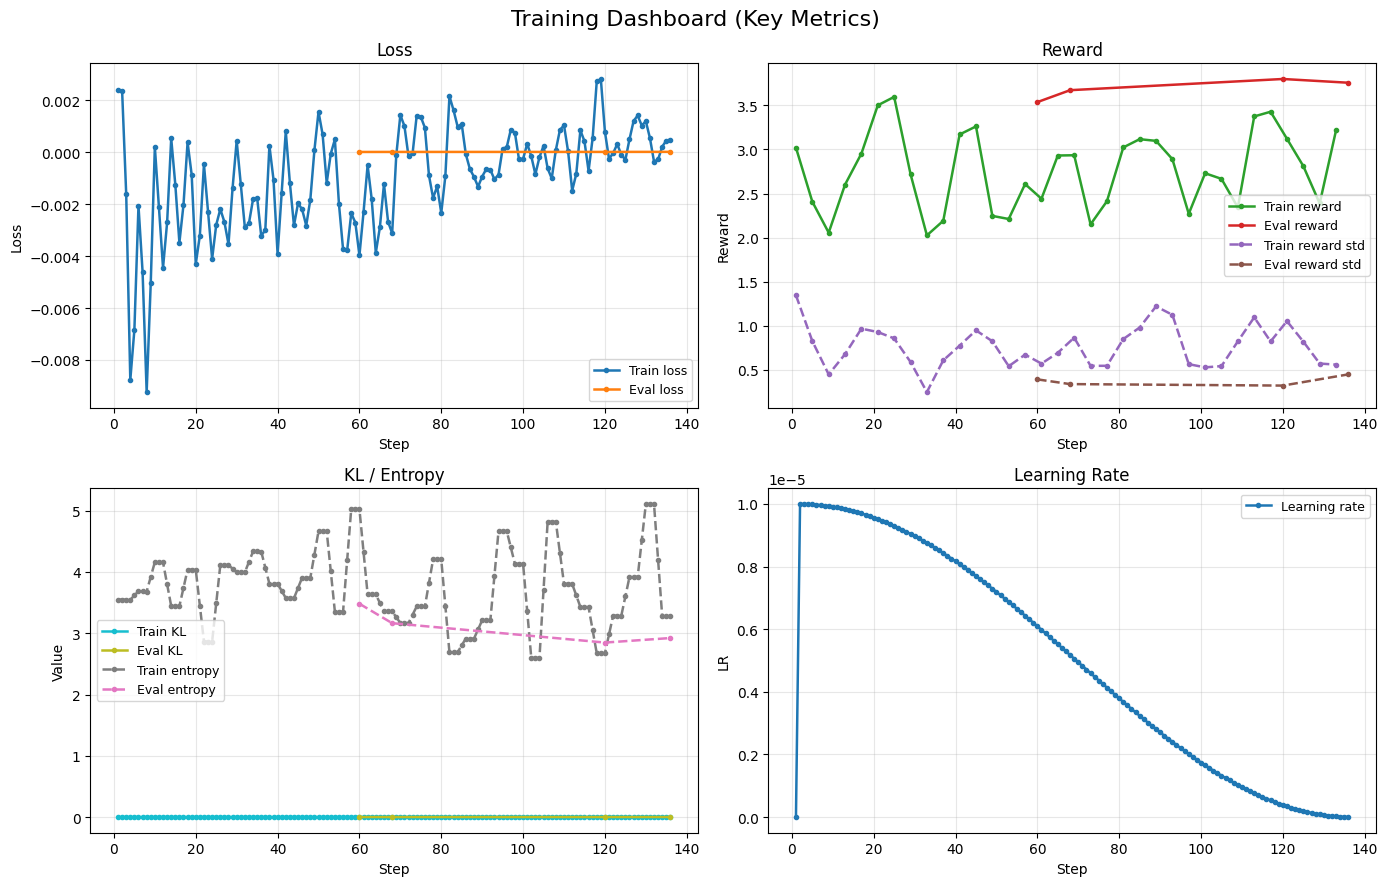


Key tags used:
  train_loss: train/loss
  eval_loss: eval/loss
  train_reward: train/reward
  eval_reward: eval/reward
  train_reward_std: train/reward_std
  eval_reward_std: eval/reward_std
  train_kl: train/kl
  eval_kl: eval/kl
  train_entropy: train/entropy
  eval_entropy: eval/entropy
  lr: train/learning_rate


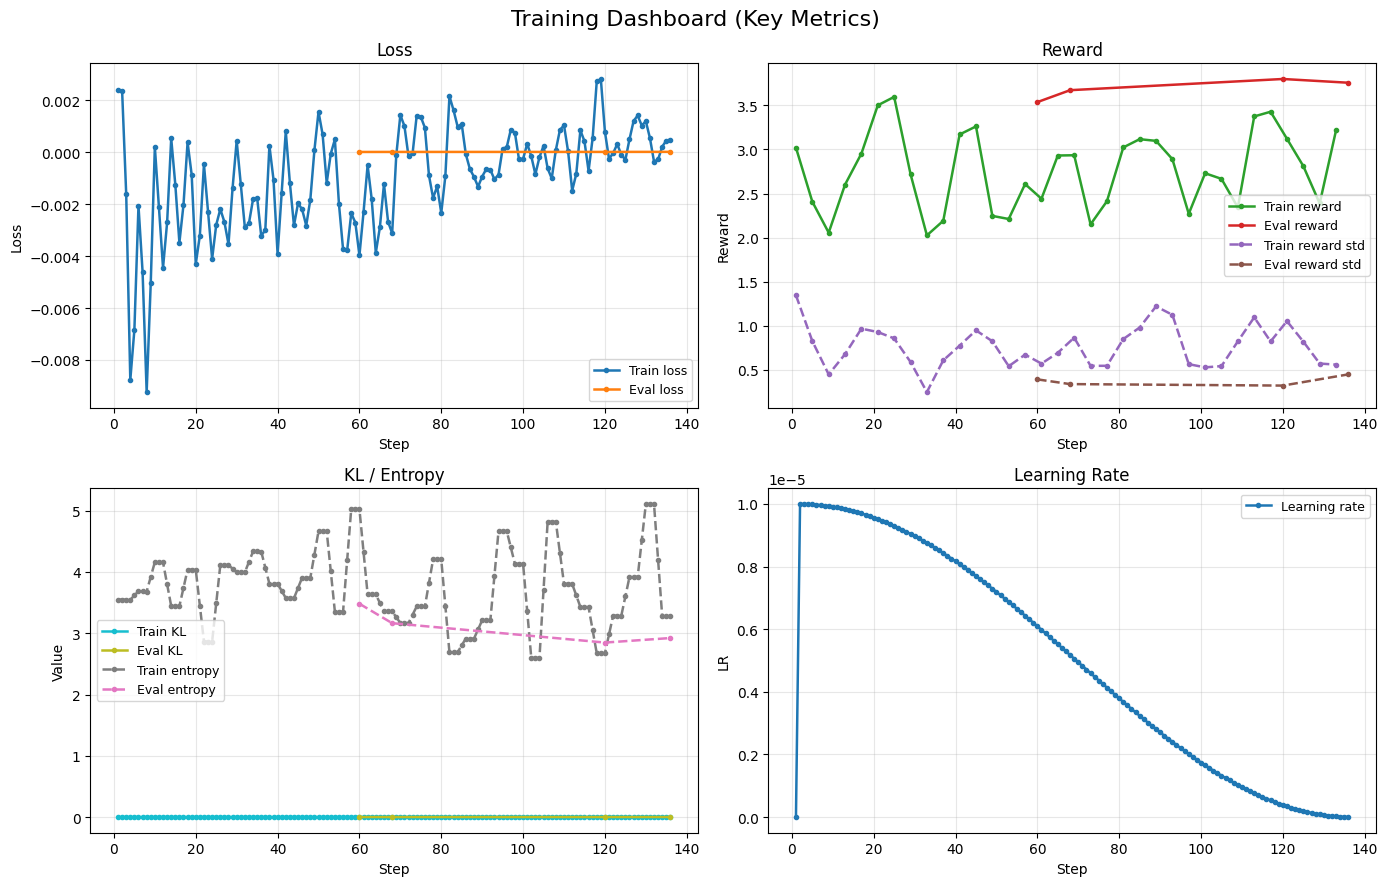

In [ ]:
%matplotlib inline

# Render the 2×2 dashboard (loss / reward / KL+entropy / LR).
plot_iteration_metrics(LOCAL_OUTDIR)
